In [1]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from PIL import Image

In [2]:
root = "/home/amzeplin/plant_village_dataset"

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

class MultiTaskEfficientNet(nn.Module):
    def __init__(self, species_classes, disease_classes):
        super(MultiTaskEfficientNet, self).__init__()

        # Load EfficientNet-B3 model
        self.efficientnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        
        # Get feature extractor
        num_ftrs = self.efficientnet.classifier[1].in_features
        
        # Remove default classifier
        self.efficientnet.classifier = nn.Identity()  # Keep feature extractor only
        
        # Two separate classification heads
        self.species_head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, species_classes)  # Output species classes
        )

        self.disease_head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, disease_classes)  # Output disease classes
        )

    def forward(self, x, task_idx):
        x = self.efficientnet(x)  # Extract features

        if task_idx == 0:  # Predict species
            return self.species_head(x)
        elif task_idx == 1:  # Predict disease
            return self.disease_head(x)
        else:
            raise ValueError("Invalid task_idx. Use 0 for species and 1 for disease.")


In [4]:
class PlantVillageMultiTask(torch.utils.data.Dataset):
    def __init__(self, root: str, split: str, transform=None):
        self.root = root
        self.species = os.listdir(self.root)
        self.img_split = split
        self.transform = transform
        self.data = self.__load_files()

        # Create label maps for species & diseases separately
        self.species_map = {species: idx for idx, species in enumerate(sorted(set(spec for _, spec, _ in self.data)))}
        self.disease_map = {disease: idx for idx, disease in enumerate(sorted(set(dis for _, _, dis in self.data)))}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_file, species, disease = self.data[idx]
        img = Image.open(img_file).convert("RGB")

        if self.transform:
            img = self.transform(img)

        # Convert labels
        species_label = torch.tensor(self.species_map[species], dtype=torch.long)
        disease_label = torch.tensor(self.disease_map[disease], dtype=torch.long)

        return img, species_label, disease_label

    def __load_files(self):
        data = []
        for species in self.species:
            specie_path = os.path.join(self.root, species, self.img_split)
            if not os.path.exists(specie_path): 
                continue

            for disease in os.listdir(specie_path):
                disease_path = os.path.join(specie_path, disease)
                if not os.path.isdir(disease_path):
                    continue

                images = [img for img in os.listdir(disease_path) if not img.startswith('.')]
                data.extend([(os.path.join(disease_path, img), species, disease) for img in images])

        return data


Data Augmentation

In [5]:
train_augmentations = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(p=0.3),  # Reduce probability
    transforms.RandomRotation(5),  # Reduce rotation angle
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Reduce jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_ds = PlantVillageMultiTask(root=root, split="Train", transform=train_augmentations)
val_ds = PlantVillageMultiTask(root=root, split="Val", transform=train_augmentations)
test_ds = PlantVillageMultiTask(root=root, split="Test", transform=train_augmentations)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

# Number of classes
num_species = len(train_ds.species_map)
num_diseases = len(train_ds.disease_map)


Train Model

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = MultiTaskEfficientNet(num_species, num_diseases).to(device)

# Loss functions
species_loss_fn = nn.CrossEntropyLoss()
disease_loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# Training function
def train_multi_task(model, train_loader, val_loader, species_loss_fn, disease_loss_fn, optimizer, epochs=5):
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct_species, correct_disease = 0, 0
        total = 0

        for images, species_labels, disease_labels in train_loader:
            images, species_labels, disease_labels = images.to(device), species_labels.to(device), disease_labels.to(device)

            optimizer.zero_grad()
            
            # Forward pass for species
            species_preds = model(images, task_idx=0)
            species_loss = species_loss_fn(species_preds, species_labels)
            
            # Forward pass for disease
            disease_preds = model(images, task_idx=1)
            disease_loss = disease_loss_fn(disease_preds, disease_labels)

            # Combined loss
            loss = species_loss + disease_loss
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, species_predicted = torch.max(species_preds, 1)
            _, disease_predicted = torch.max(disease_preds, 1)

            correct_species += (species_predicted == species_labels).sum().item()
            correct_disease += (disease_predicted == disease_labels).sum().item()
            total += species_labels.size(0)

        train_species_acc = 100 * correct_species / total
        train_disease_acc = 100 * correct_disease / total

        # Validate
        val_species_acc, val_disease_acc = evaluate(model, val_loader)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Species Acc: {train_species_acc:.2f}%, Disease Acc: {train_disease_acc:.2f}%, Val Species Acc: {val_species_acc:.2f}%, Val Disease Acc: {val_disease_acc:.2f}%")

    print("Training Complete!")

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct_species, correct_disease, total = 0, 0, 0

    with torch.no_grad():
        for images, species_labels, disease_labels in loader:
            images, species_labels, disease_labels = images.to(device), species_labels.to(device), disease_labels.to(device)

            species_preds = model(images, task_idx=0)
            disease_preds = model(images, task_idx=1)

            _, species_predicted = torch.max(species_preds, 1)
            _, disease_predicted = torch.max(disease_preds, 1)

            correct_species += (species_predicted == species_labels).sum().item()
            correct_disease += (disease_predicted == disease_labels).sum().item()
            total += species_labels.size(0)

    return 100 * correct_species / total, 100 * correct_disease / total

# Start training
train_multi_task(model, train_loader, val_loader, species_loss_fn, disease_loss_fn, optimizer, epochs=5)


Epoch [1/5], Loss: 615.1673, Species Acc: 96.48%, Disease Acc: 92.81%, Val Species Acc: 99.92%, Val Disease Acc: 99.53%
Epoch [2/5], Loss: 53.4364, Species Acc: 99.78%, Disease Acc: 99.22%, Val Species Acc: 99.83%, Val Disease Acc: 99.42%
Epoch [3/5], Loss: 30.8479, Species Acc: 99.88%, Disease Acc: 99.56%, Val Species Acc: 99.21%, Val Disease Acc: 99.20%
Epoch [4/5], Loss: 33.8984, Species Acc: 99.80%, Disease Acc: 99.57%, Val Species Acc: 99.98%, Val Disease Acc: 99.68%
Epoch [5/5], Loss: 27.9935, Species Acc: 99.87%, Disease Acc: 99.61%, Val Species Acc: 99.89%, Val Disease Acc: 99.35%
Training Complete!


In [37]:
# Function to compute test accuracy
def test_multi_task(model, loader):
    model.eval()
    correct_species, correct_disease, total = 0, 0, 0

    with torch.no_grad():
        for images, species_labels, disease_labels in loader:
            images, species_labels, disease_labels = images.to(device), species_labels.to(device), disease_labels.to(device)

            species_preds = model(images, task_idx=0)
            disease_preds = model(images, task_idx=1)

            _, species_predicted = torch.max(species_preds, 1)
            _, disease_predicted = torch.max(disease_preds, 1)

            correct_species += (species_predicted == species_labels).sum().item()
            correct_disease += (disease_predicted == disease_labels).sum().item()
            total += species_labels.size(0)

    species_acc = 100 * correct_species / total
    disease_acc = 100 * correct_disease / total

    print(f"Test Accuracy - Species: {species_acc:.2f}%, Disease: {disease_acc:.2f}%")
    return species_acc, disease_acc

# Run test evaluation
test_species_acc, test_disease_acc = test_multi_task(model, test_loader)


TypeError: EfficientNet.forward() got an unexpected keyword argument 'task_idx'

Save Model

In [10]:
torch.save(model.state_dict(), "efficientnet_multitask.pth")
print("Model saved successfully!")


Model saved successfully!


Load device 

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load Model

In [8]:
# Load model
model = MultiTaskEfficientNet(num_species, num_diseases).to(device)
model.load_state_dict(torch.load("efficientnet_multitask.pth"))
model.eval()
print("Model loaded successfully!")


Model loaded successfully!


Test Predicted vs Actual Accuracy

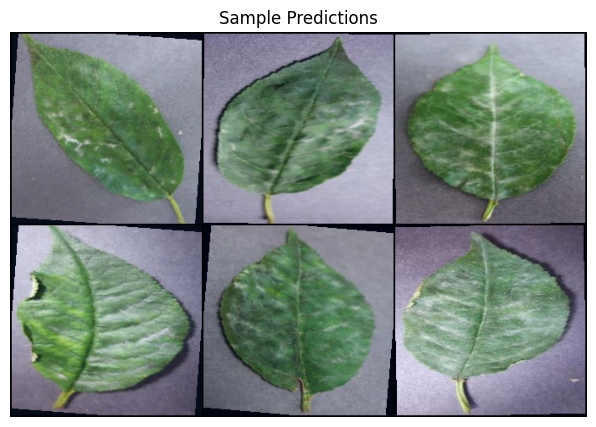

Image 1:
   True Species: Cherry, Predicted: Cherry Correct
   True Disease: Powdery Mildew, Predicted: Powdery Mildew Correct
Image 2:
   True Species: Cherry, Predicted: Cherry Correct
   True Disease: Powdery Mildew, Predicted: Powdery Mildew Correct
Image 3:
   True Species: Cherry, Predicted: Cherry Correct
   True Disease: Powdery Mildew, Predicted: Powdery Mildew Correct
Image 4:
   True Species: Cherry, Predicted: Cherry Correct
   True Disease: Powdery Mildew, Predicted: Powdery Mildew Correct
Image 5:
   True Species: Cherry, Predicted: Cherry Correct
   True Disease: Powdery Mildew, Predicted: Powdery Mildew Correct
Image 6:
   True Species: Cherry, Predicted: Cherry Correct
   True Disease: Powdery Mildew, Predicted: Powdery Mildew Correct


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

# Function to display images and predictions
def show_sample_predictions(loader, dataset, model, num_images=6):
    model.eval()
    
    images, species_labels, disease_labels = next(iter(loader))
    images = images[:num_images]  # Take only the first few images
    species_labels = species_labels[:num_images]
    disease_labels = disease_labels[:num_images]

    # Convert images to numpy format for plotting
    img_grid = make_grid(images, nrow=3, normalize=True).numpy()
    img_grid = np.transpose(img_grid, (1, 2, 0))  # Convert from (C, H, W) to (H, W, C)

    # Display the images
    plt.figure(figsize=(10, 5))
    plt.imshow(img_grid)
    plt.axis("off")
    plt.title("Sample Predictions")
    plt.show()

    # Convert tensor images to GPU if available
    images = images.to(device)

    with torch.no_grad():
        species_preds = model(images, task_idx=0)
        disease_preds = model(images, task_idx=1)

        _, species_predicted = torch.max(species_preds, 1)
        _, disease_predicted = torch.max(disease_preds, 1)

    # Convert label indices to class names
    idx_to_species = {v: k for k, v in dataset.species_map.items()}
    idx_to_disease = {v: k for k, v in dataset.disease_map.items()}

    for i, (true_species, true_disease, pred_species, pred_disease) in enumerate(zip(species_labels, disease_labels, species_predicted, disease_predicted)):
        true_species_name = idx_to_species[true_species.item()]
        true_disease_name = idx_to_disease[true_disease.item()]
        pred_species_name = idx_to_species[pred_species.item()]
        pred_disease_name = idx_to_disease[pred_disease.item()]

        correctness_species = "Correct" if true_species_name == pred_species_name else "Incorrect"
        correctness_disease = "Correct" if true_disease_name == pred_disease_name else "Incorrect"

        print(f"Image {i+1}:")
        print(f"   True Species: {true_species_name}, Predicted: {pred_species_name} {correctness_species}")
        print(f"   True Disease: {true_disease_name}, Predicted: {pred_disease_name} {correctness_disease}")

# Show sample predictions
show_sample_predictions(test_loader, test_ds, model)



Confusion Matrix for Species and Disease

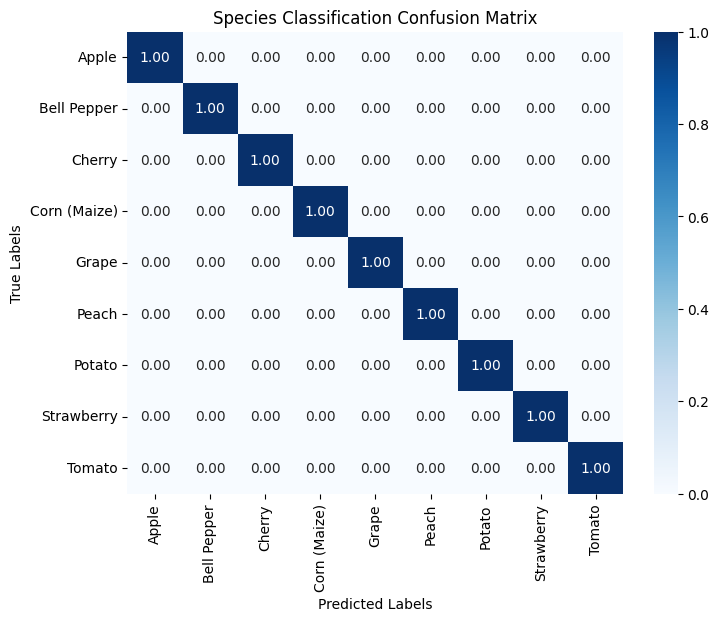

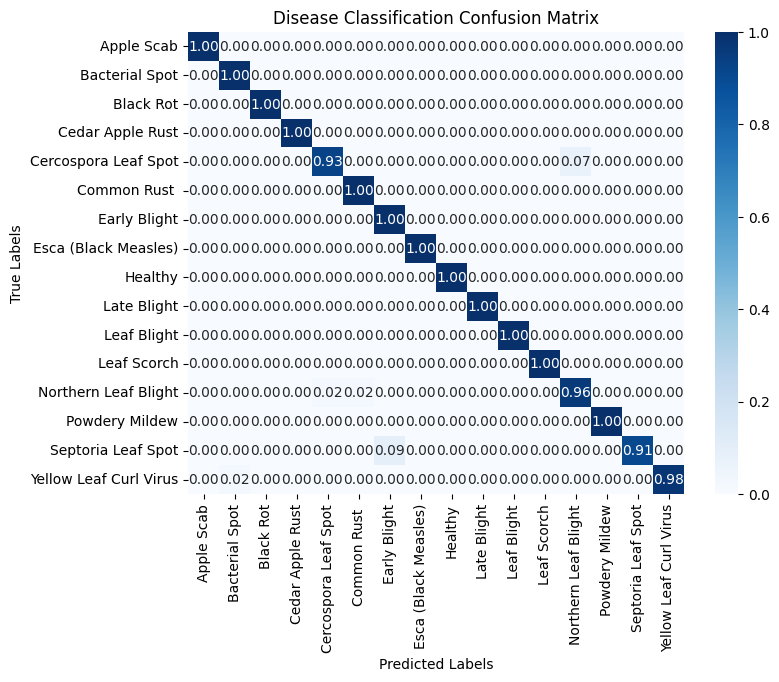

In [62]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_and_plot_confusion_matrix(model, loader, species_classes, disease_classes):
    model.eval()  # Set model to evaluation mode

    all_species_preds = []
    all_species_labels = []
    all_disease_preds = []
    all_disease_labels = []

    with torch.no_grad():  # Disable gradient tracking
        for images, species_labels, disease_labels in loader:
            images = images.to(device)
            species_labels = species_labels.to(device)
            disease_labels = disease_labels.to(device)

            # Get model predictions for both tasks
            species_preds = model(images, task_idx=0)
            disease_preds = model(images, task_idx=1)

            # Convert predictions to class indices
            _, species_predicted = torch.max(species_preds, 1)
            _, disease_predicted = torch.max(disease_preds, 1)

            # Store predictions and true labels
            all_species_preds.extend(species_predicted.cpu().numpy())
            all_species_labels.extend(species_labels.cpu().numpy())
            all_disease_preds.extend(disease_predicted.cpu().numpy())
            all_disease_labels.extend(disease_labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_species_preds = np.array(all_species_preds)
    all_species_labels = np.array(all_species_labels)
    all_disease_preds = np.array(all_disease_preds)
    all_disease_labels = np.array(all_disease_labels)

    # Generate confusion matrices
    species_cm = confusion_matrix(all_species_labels, all_species_preds, normalize='true')
    disease_cm = confusion_matrix(all_disease_labels, all_disease_preds, normalize='true')

    # Plot confusion matrices
    plot_confusion_matrix(species_cm, species_classes, title="Species Classification Confusion Matrix")
    plot_confusion_matrix(disease_cm, disease_classes, title="Disease Classification Confusion Matrix")

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


species_classes = list(train_ds.species_map.keys())  # Get class names for species
disease_classes = list(train_ds.disease_map.keys())  # Get class names for diseases

evaluate_and_plot_confusion_matrix(model, test_loader, species_classes, disease_classes)


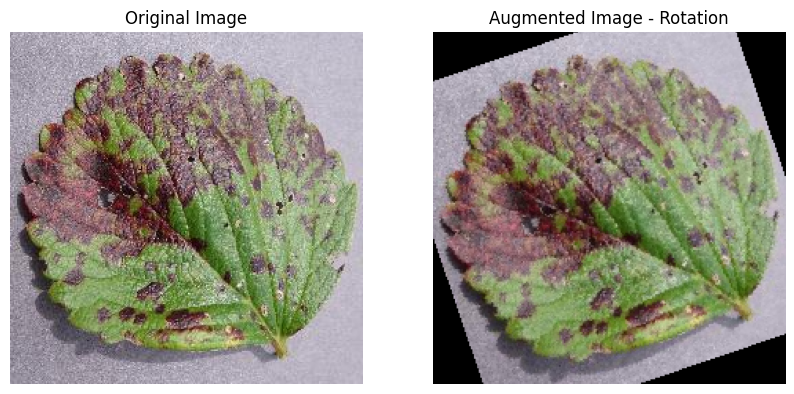

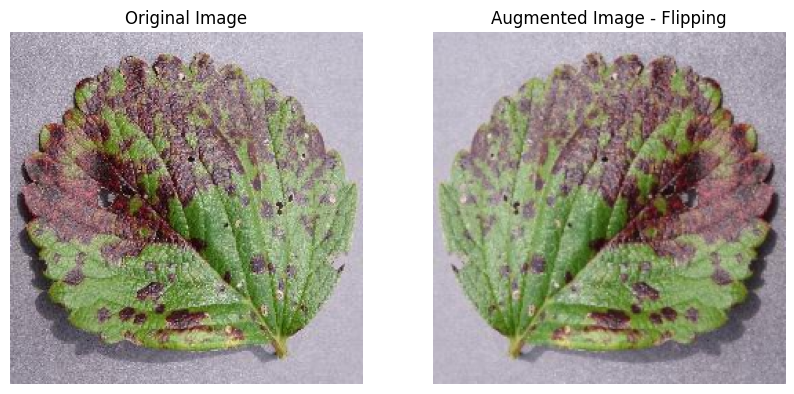

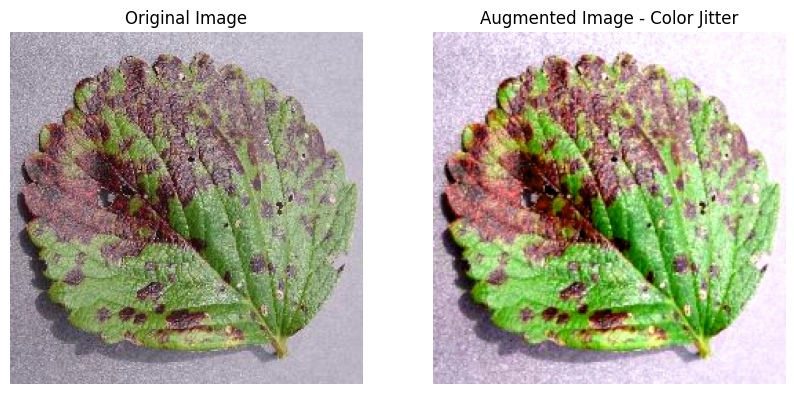

In [32]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ✅ Load a Sample Image from PlantVillage
def load_sample_image(dataset):
    img_path, _, _ = dataset.data[9304]  # Get first image from dataset
    img = Image.open(img_path).convert("RGB")  # Open and convert to RGB
    return img

# ✅ Function to Apply and Display One Augmentation at a Time
def visualize_single_augmentation(dataset, transform, transform_name):
    original_img = load_sample_image(dataset)  # Load original image
    augmented_img = transform(original_img)  # Apply only one transformation

    # Convert tensor to numpy image for visualization
    def tensor_to_image(tensor):
        tensor = tensor.clone().detach().cpu().numpy()  # Convert to NumPy
        tensor = np.transpose(tensor, (1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
        tensor = tensor * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        tensor = np.clip(tensor, 0, 1)  # Clip values to valid range
        return tensor

    # Convert tensors to images
    augmented_img_np = tensor_to_image(augmented_img)

    # ✅ Plot Images Side by Side
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_img)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(augmented_img_np)
    ax[1].set_title(f"Augmented Image - {transform_name}")
    ax[1].axis("off")

    plt.show()

# ✅ Define Individual Transformations

# Rotation Only
rotation_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomRotation(30),  # Rotate randomly between -30° and +30°
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Flipping Only
flip_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(p=1.0),  # Always flip horizontally
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Color Jitter Only
color_jitter_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),  # Stronger effect
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ✅ Run the function with different augmentations

# Show Rotated Image
visualize_single_augmentation(train_ds, rotation_transform, "Rotation")

# Show Flipped Image
visualize_single_augmentation(train_ds, flip_transform, "Flipping")

# Show Color Jittered Image
visualize_single_augmentation(train_ds, color_jitter_transform, "Color Jitter")


In [50]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# ✅ Preprocessing function for Google Images
def preprocess_image(image_url):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
    ])
    
    # Download image from URL
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")  # Convert to RGB
    
    # Apply transformations
    processed_image = transform(image).unsqueeze(0)  # Add batch dimension
    return processed_image.to("cuda" if torch.cuda.is_available() else "cpu"), image  # Return original & processed images


In [51]:
def predict_google_image(image_url, model, species_map, disease_map):
    model.eval()  # Set model to evaluation mode
    
    # Preprocess the image
    processed_image, original_image = preprocess_image(image_url)

    with torch.no_grad():  # Disable gradient calculation
        # Get predictions from the model
        species_preds = model(processed_image, task_idx=0)
        disease_preds = model(processed_image, task_idx=1)

        # Convert predictions to class indices
        _, species_predicted = torch.max(species_preds, 1)
        _, disease_predicted = torch.max(disease_preds, 1)

    # Convert class indices back to class names
    species_class = list(species_map.keys())[list(species_map.values()).index(species_predicted.item())]
    disease_class = list(disease_map.keys())[list(disease_map.values()).index(disease_predicted.item())]

    # ✅ Display the image with predictions
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image)
    plt.axis("off")
    plt.title(f"🌱 Predicted Species: {species_class}\n🦠 Predicted Disease: {disease_class}", fontsize=12)
    plt.show()

    print(f"🌱 Predicted Species: {species_class}")
    print(f"🦠 Predicted Disease: {disease_class}")

    return species_class, disease_class


In [11]:
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image

# ✅ Load Pretrained Model (Make sure your model is already trained)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskEfficientNet(num_species, num_diseases).to(device)
model.load_state_dict(torch.load("efficientnet_multitask.pth", map_location=device))  # Load trained model
model.eval()  # Set to evaluation mode

# ✅ Preprocessing Function (Improved for Google Images)
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize(256),  # Maintain aspect ratio
        transforms.CenterCrop(224),  # Crop center 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    if isinstance(image, str):  # If input is a file path, open the image
        image = Image.open(image).convert("RGB")

    image = transform(image).unsqueeze(0)  # Convert to tensor and add batch dimension
    return image.to(device)  # Move to GPU if available

# ✅ Temperature Scaling for Confidence Calibration
def calibrated_predict(model, image, temperature=2.0):
    with torch.no_grad():
        species_output = model(image, task_idx=0)  # Predict species
        disease_output = model(image, task_idx=1)  # Predict disease

        # Apply Softmax with Temperature Scaling
        species_probs = F.softmax(species_output / temperature, dim=1)
        disease_probs = F.softmax(disease_output / temperature, dim=1)

        species_pred = torch.argmax(species_probs, 1).item()
        disease_pred = torch.argmax(disease_probs, 1).item()

    return species_pred, disease_pred

# ✅ Test-Time Augmentation (TTA) - Averaging Multiple Crops
def tta_predict(model, image):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.TenCrop(224),  # Generate 10 crops
        transforms.Lambda(lambda crops: torch.stack([transforms.ToTensor()(crop) for crop in crops])),
        transforms.Lambda(lambda crops: torch.stack([transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(crop) for crop in crops]))
    ])

    image = transform(image).to(device)  # Shape [10, C, H, W]
    
    with torch.no_grad():
        species_outputs = model(image, task_idx=0)  # Predict for all crops
        disease_outputs = model(image, task_idx=1)

    species_pred = torch.argmax(species_outputs.mean(dim=0))  # Average predictions
    disease_pred = torch.argmax(disease_outputs.mean(dim=0))

    return species_pred.item(), disease_pred.item()

# ✅ Google Image Prediction Function
def predict_from_url(image_url, model, dataset):
    # Download image from URL
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")

    # Preprocess image
    processed_image = preprocess_image(image)

    # Predict with temperature scaling
    species_pred, disease_pred = calibrated_predict(model, processed_image)

    # Get class names
    idx_to_species = {v: k for k, v in dataset.species_map.items()}
    idx_to_disease = {v: k for k, v in dataset.disease_map.items()}

    predicted_species = idx_to_species[species_pred]
    predicted_disease = idx_to_disease[disease_pred]

    print(f" Predicted Species: {predicted_species}")
    print(f" Predicted Disease: {predicted_disease}")

    return predicted_species, predicted_disease

# ✅ Example: Test with a Google Image
image_url = "https://content.peat-cloud.com/w400/esca-grape-1665660551.jpg"
predict_from_url(image_url, model, train_ds)


 Predicted Species: Tomato
 Predicted Disease: Early Blight


('Tomato', 'Early Blight')

In [6]:
import torch

# ✅ First, rebuild the model architecture
num_species = len(train_ds.species_map)  # Get number of species classes
num_diseases = len(train_ds.disease_map)  # Get number of disease classes

model = MultiTaskEfficientNet(num_species, num_diseases)  # Re-initialize model

# ✅ Load the previously saved weights
model.load_state_dict(torch.load("efficientnet_multitask.pth", map_location="cuda" if torch.cuda.is_available() else "cpu", weights_only=True))

# ✅ Save the full model (architecture + weights)
torch.save(model, "efficientnet_multitask_full.pth")  
print("Full model saved successfully!")


Full model saved successfully!


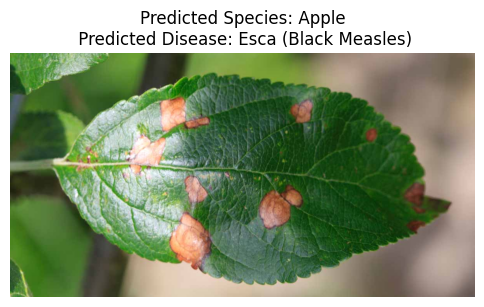

In [ ]:
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image

# ✅ Load Pretrained Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskEfficientNet(num_species, num_diseases).to(device)
model.load_state_dict(torch.load("efficientnet_multitask.pth", map_location=device))  # Load trained model
model.eval()  # Set to evaluation mode

# ✅ Preprocessing Function
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize(256),  # Maintain aspect ratio
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.ColorJitter(brightness=0.25, contrast=0.75, saturation=0.1, hue=0)
    ])

    if isinstance(image, str):
        image = Image.open(image).convert("RGB")

    image = transform(image).unsqueeze(0)  
    return image.to(device)

# ✅ Prediction Function
def predict_image(image, model, dataset, temperature=2.0):
    processed_image = preprocess_image(image)

    with torch.no_grad():
        species_output = model(processed_image, task_idx=0)  
        disease_output = model(processed_image, task_idx=1)

        # Apply Softmax with Temperature Scaling
        species_probs = F.softmax(species_output / temperature, dim=1)
        disease_probs = F.softmax(disease_output / temperature, dim=1)

        species_pred = torch.argmax(species_probs, 1).item()
        disease_pred = torch.argmax(disease_probs, 1).item()

    idx_to_species = {v: k for k, v in dataset.species_map.items()}
    idx_to_disease = {v: k for k, v in dataset.disease_map.items()}

    return idx_to_species[species_pred], idx_to_disease[disease_pred]

# ✅ Display Image and Prediction
def show_image_with_prediction(image_url, model, dataset):
    # Download and open image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")

    # Predict species and disease
    predicted_species, predicted_disease = predict_image(image, model, dataset)

    # Display Image with Prediction
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted Species: {predicted_species}\n Predicted Disease: {predicted_disease}", fontsize=12)
    plt.show()

# ✅ Example: Test with Google Image
image_url = "https://gardenerspath.com/wp-content/uploads/2019/08/Frogeye-spots-Botryosphaeria-obtusa-on-apple-leaf-FB.jpg"
show_image_with_prediction(image_url, model, train_ds)
